In [3]:
import pandas as pd
import numpy as np

from prophet import Prophet

In [5]:
df_path = "/home/asad/Desktop/footfall_explorer/data/rossmann-store-sales/train.csv"
df = pd.read_csv(df_path, low_memory=False)

In [6]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [19]:
## As we have multiple stores, we will do it for a single store and then we can do the same analysis for all the sotres as well. 
df_store1 = df[df['Store'] == 1].copy()

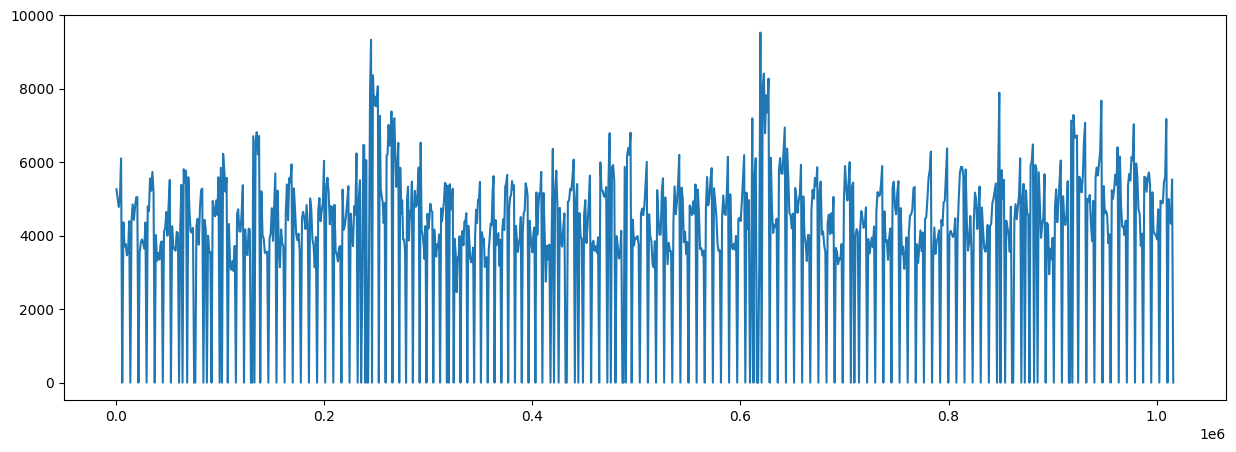

In [20]:
# df_store1.iloc[0:50]['Sales'].plot(figsize=(15, 5));
df_store1['Sales'].plot(figsize=(15, 5)); # The sales go down to zero, check from first line result. 

In [22]:
# Let's check how many are with sales 0.
(df_store1[df_store1['Sales'] == 0]).sum()

Store                                                          161
DayOfWeek                                                     1029
Date             2015-07-262015-07-192015-07-122015-07-052015-0...
Sales                                                            0
Customers                                                        0
Open                                                             0
Promo                                                           10
StateHoliday     00000000a0a00a00a000b0b0000000000000a0cc000000...
SchoolHoliday                                                   33
dtype: object

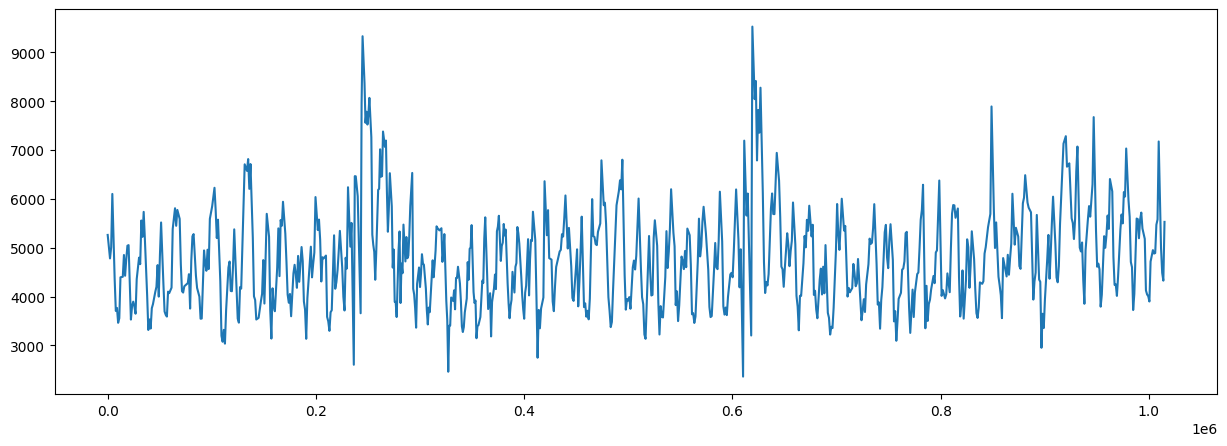

In [24]:
# The sales is zero because on these days the store is closed. 
df_store1[df_store1['Open'] > 0]["Sales"].plot(figsize=(15, 5));

In [26]:
print(df_store1.shape)
df_store1['Date'] = pd.to_datetime(df_store1['Date'])
df_store1.set_index("Date", inplace=True)

(942, 9)


In [28]:
df_store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


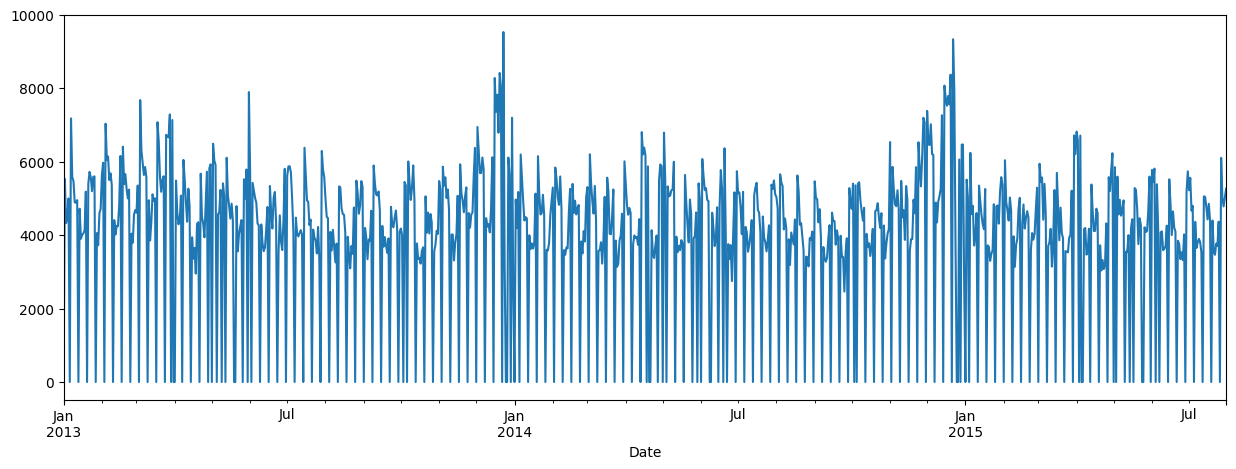

In [30]:
# Now if we plot the data, we will see the date in below instead of some random numbers.
df_store1["Sales"].plot(figsize=(15, 5));

In [31]:
df_p = df_store1[['Sales']].copy()

In [32]:
df_p['Date'] = df_p.index

df_p.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [33]:
df_p.sort_index(inplace=True)

df_p.head()

,Sales,Date
Date,,
2013-01-01,0,2013-01-01
2013-01-02,5530,2013-01-02
2013-01-03,4327,2013-01-03
2013-01-04,4486,2013-01-04
2013-01-05,4997,2013-01-05


In [34]:
df_p.columns = ['y', 'ds']

df_p.head()

,y,ds
Date,,
2013-01-01,0,2013-01-01
2013-01-02,5530,2013-01-02
2013-01-03,4327,2013-01-03
2013-01-04,4486,2013-01-04
2013-01-05,4997,2013-01-05


In [35]:
m = Prophet()

In [36]:
m.fit(df=df_p)

14:07:04 - cmdstanpy - INFO - Chain [1] start processing
14:07:04 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
future = m.make_future_dataframe(365)

In [38]:
future.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [39]:
future.tail()

,ds
1302,2016-07-26
1303,2016-07-27
1304,2016-07-28
1305,2016-07-29
1306,2016-07-30


In [40]:
forecast = m.predict(future)

In [47]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1302,2016-07-26,3737.005878,3021.102778,5943.083155,3713.237068,3761.908266,712.974248,712.974248,712.974248,706.324552,706.324552,706.324552,6.649696,6.649696,6.649696,0.0,0.0,0.0,4449.980127
1303,2016-07-27,3736.789772,2781.750687,5750.577486,3712.914100,3761.836236,502.197254,502.197254,502.197254,510.550255,510.550255,510.550255,-8.353002,-8.353002,-8.353002,0.0,0.0,0.0,4238.987025
1304,2016-07-28,3736.573665,2443.502477,5229.096537,3712.591132,3761.764205,126.298672,126.298672,126.298672,151.278600,151.278600,151.278600,-24.979928,-24.979928,-24.979928,0.0,0.0,0.0,3862.872336
1305,2016-07-29,3736.357558,2814.705567,5718.302869,3712.266925,3761.695566,530.728945,530.728945,530.728945,573.627066,573.627066,573.627066,-42.898122,-42.898122,-42.898122,0.0,0.0,0.0,4267.086503
1306,2016-07-30,3736.141451,3277.898185,6179.720646,3711.948358,3761.656780,937.348274,937.348274,937.348274,999.102507,999.102507,999.102507,-61.754232,-61.754232,-61.754232,0.0,0.0,0.0,4673.489726


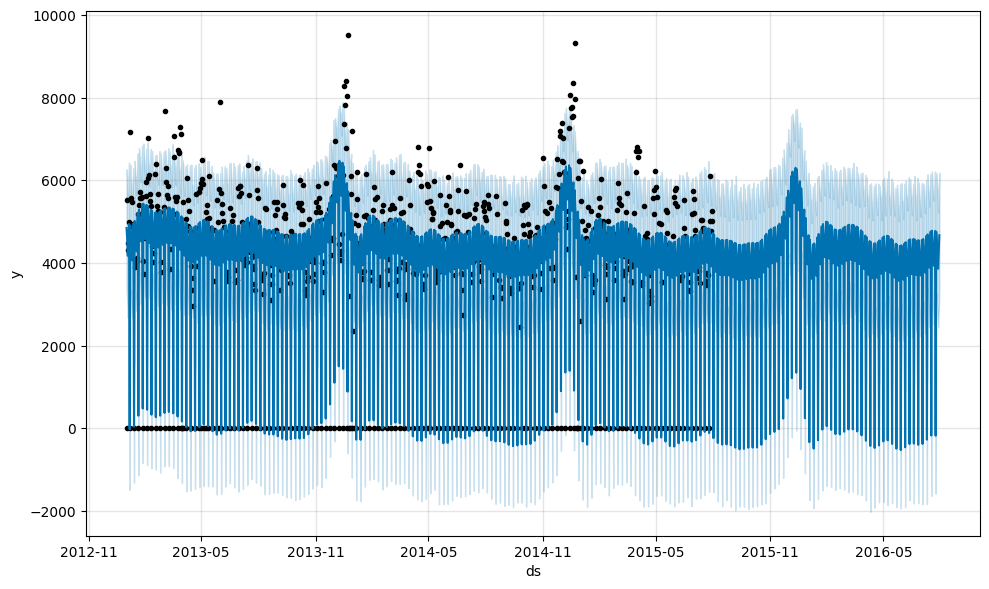

In [54]:
m.plot(forecast);

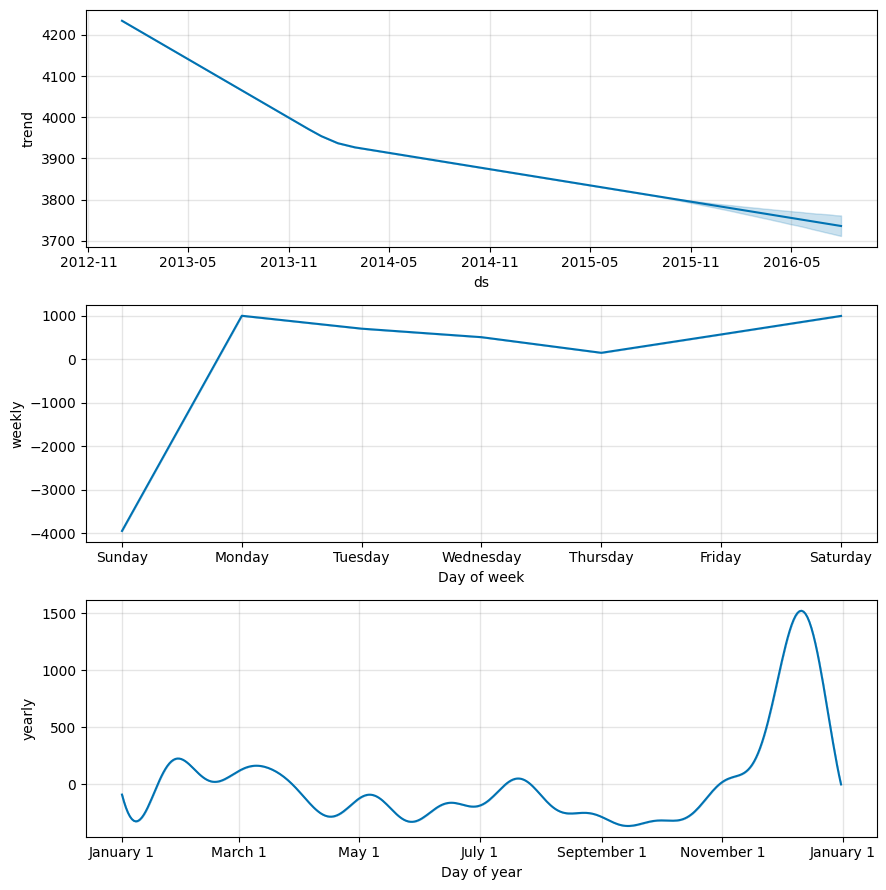

In [53]:
m.plot_components(forecast);

In [55]:
# As the large peaks around the christmas holidays which make sense as well. 
# Also we can see that we got a negative values for Sunday which we included in our dataset. 

### Let's now do it only for open days. 

In [59]:
df_p2 = df_store1[df_store1['Open'] > 0][['Sales']].copy()
df_p2['Date'] = df_p2.index
df_p2.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [60]:
df_p2.columns = ['y', 'ds']

In [62]:
m2 = Prophet().fit(df_p2)

14:24:48 - cmdstanpy - INFO - Chain [1] start processing
14:24:48 - cmdstanpy - INFO - Chain [1] done processing


In [63]:
future2 = m2.make_future_dataframe(365)

forecast2 = m2.predict(future2)

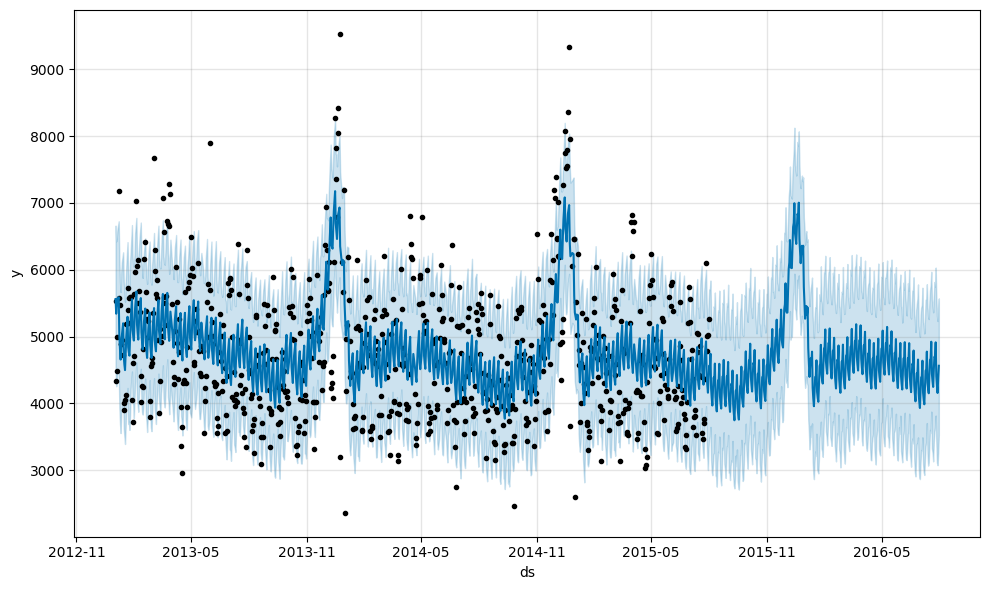

In [64]:
m2.plot(forecast2);

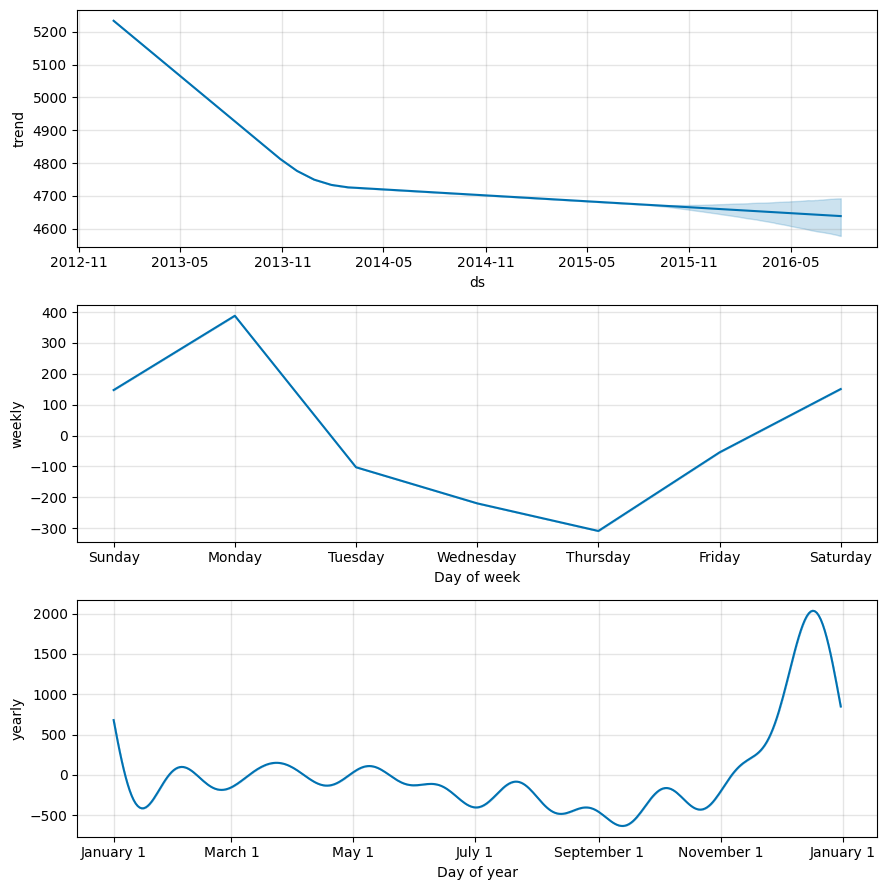

In [65]:
m2.plot_components(forecast2);

### Next we will add the countries holidays into this. 

In [66]:
m3 = Prophet()

In [67]:
m3.add_country_holidays(country_name='US')

In [68]:
m3.fit(df_p2)

14:32:27 - cmdstanpy - INFO - Chain [1] start processing
14:32:27 - cmdstanpy - INFO - Chain [1] done processing


In [69]:
forecast3 = m3.predict(m3.make_future_dataframe(365))

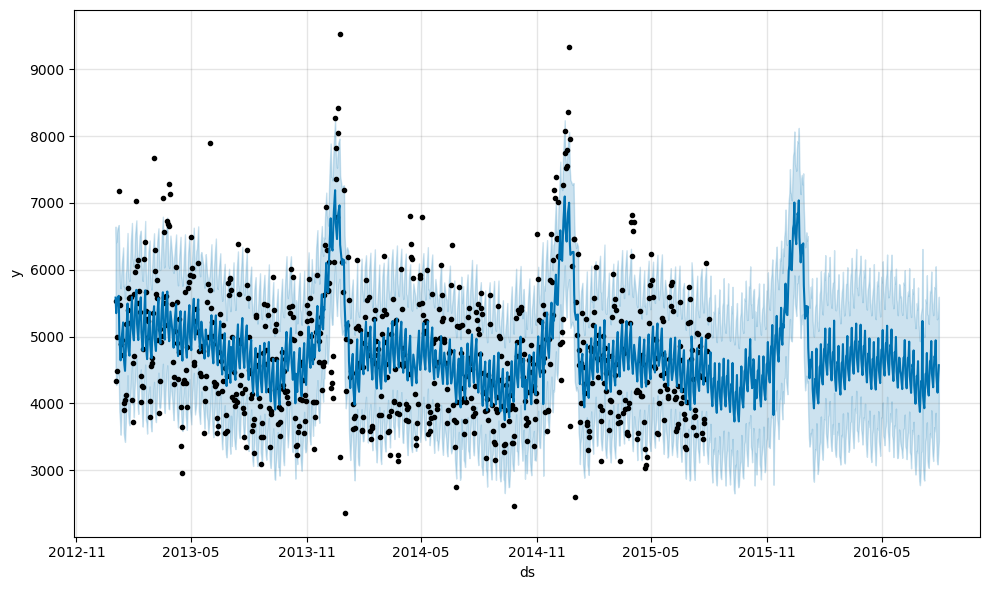

In [70]:
m3.plot(forecast3);

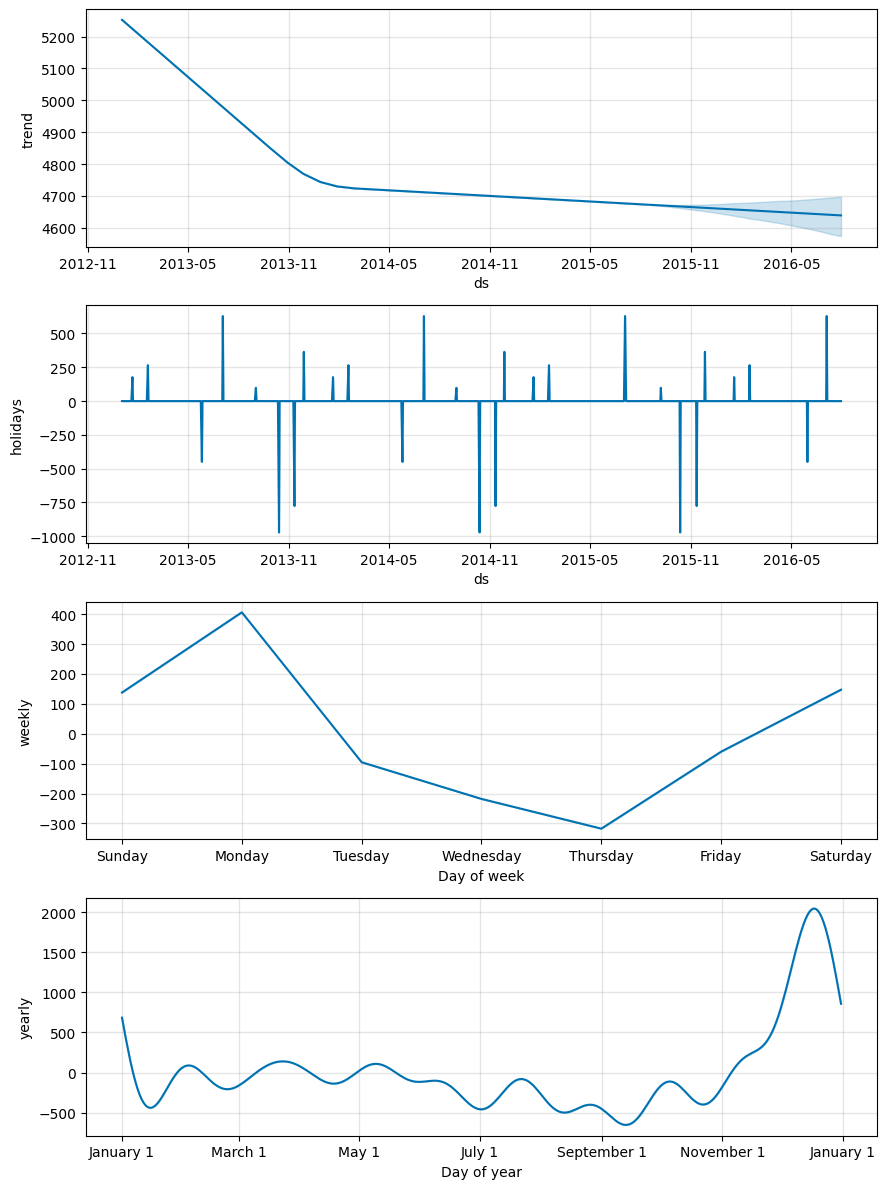

In [71]:
m3.plot_components(forecast3);

### Add Regressors to it

In [72]:
df_store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


In [74]:
# Let's see the unique values for school and country holidays. 
print(set(df_store1['StateHoliday']))
print(set(df_store1['SchoolHoliday']))


{'0', 'b', 'c', 'a'}
{0, 1}


In [80]:
df_p['open'] = df_store1['Open']
df_p['promo'] = df_store1['Promo']
df_p[['SH1', 'SH2', 'SH3']] = pd.get_dummies(df_store1['StateHoliday'], drop_first=True)
df_p['SchoolHoliday'] = df_store1['SchoolHoliday']

In [83]:
# df['SchoolHoliday'].unique()
df_p.head()

,y,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
Date,,,,,,,,
2013-01-01,0,2013-01-01,0,0,True,False,False,1
2013-01-02,5530,2013-01-02,1,0,False,False,False,1
2013-01-03,4327,2013-01-03,1,0,False,False,False,1
2013-01-04,4486,2013-01-04,1,0,False,False,False,1
2013-01-05,4997,2013-01-05,1,0,False,False,False,1


In [85]:
# Let's add regressor
m4 = Prophet()
m4.add_regressor('open', mode='multiplicative')
m4.add_regressor('promo', mode='additive')
m4.add_regressor('SH1', mode='additive')
m4.add_regressor('SH2', mode='additive')
m4.add_regressor('SH3', mode='additive')
m4.add_regressor('SchoolHoliday', mode='additive')

m4.fit(df_p)


15:37:47 - cmdstanpy - INFO - Chain [1] start processing
15:37:48 - cmdstanpy - INFO - Chain [1] done processing


In [88]:
future4 = m4.make_future_dataframe(365)

In [89]:
train_idx = future4['ds'].isin(df_p.index)
test_idx = ~train_idx

In [ ]:
# As we get the regressor for training from training data. 
regressors = ['open', 'promo', 'SH1', 'SH2', 'SH3', 'SchoolHoliday']
for r in regressors:
    future4.loc[train_idx, r] = df_p[r].to_list()

/tmp/ipykernel_19315/162223822.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, F

In [93]:
# Now for test, we will assume that the store will be closed on Sunday, as we see from the data.
# Also, we will use the previous 365 days for for other regressors. 
# In real world, this data will be provided to us. 

future4.loc[test_idx, 'open'] = future4.loc[test_idx, 'ds'].apply(lambda x: 1.0 * (x.weekday() != 6))

for r in regressors[1:]:
    future4.loc[test_idx, r] = df_p.iloc[-365:][r].to_list()

In [97]:
future4.tail()

,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
1302,2016-07-26,1.0,1.0,False,False,False,1.0
1303,2016-07-27,1.0,1.0,False,False,False,1.0
1304,2016-07-28,1.0,1.0,False,False,False,1.0
1305,2016-07-29,1.0,1.0,False,False,False,1.0
1306,2016-07-30,1.0,1.0,False,False,False,1.0


In [98]:
forecast4 = m4.predict(future4)

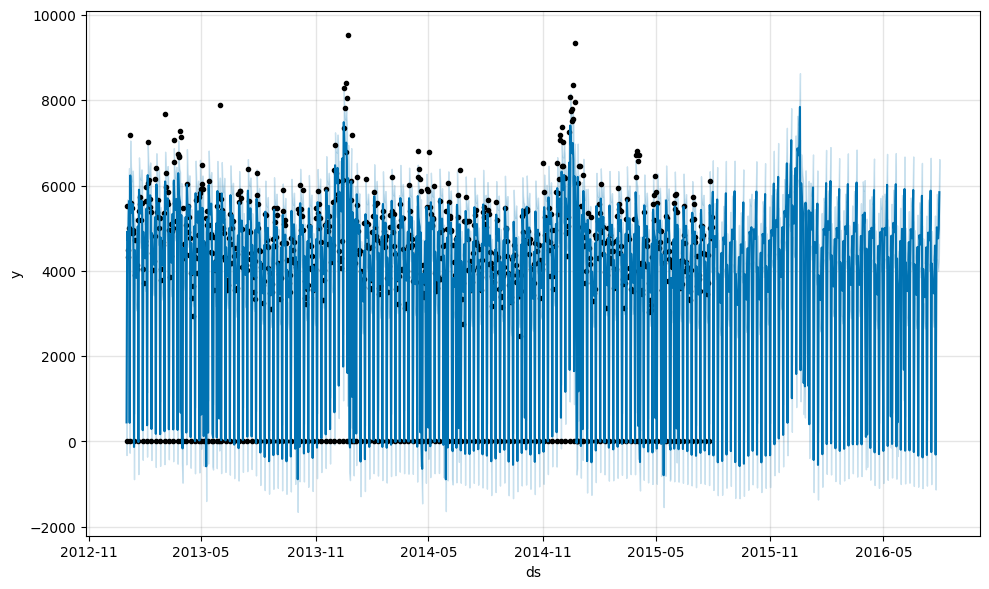

In [100]:
m4.plot(forecast4);

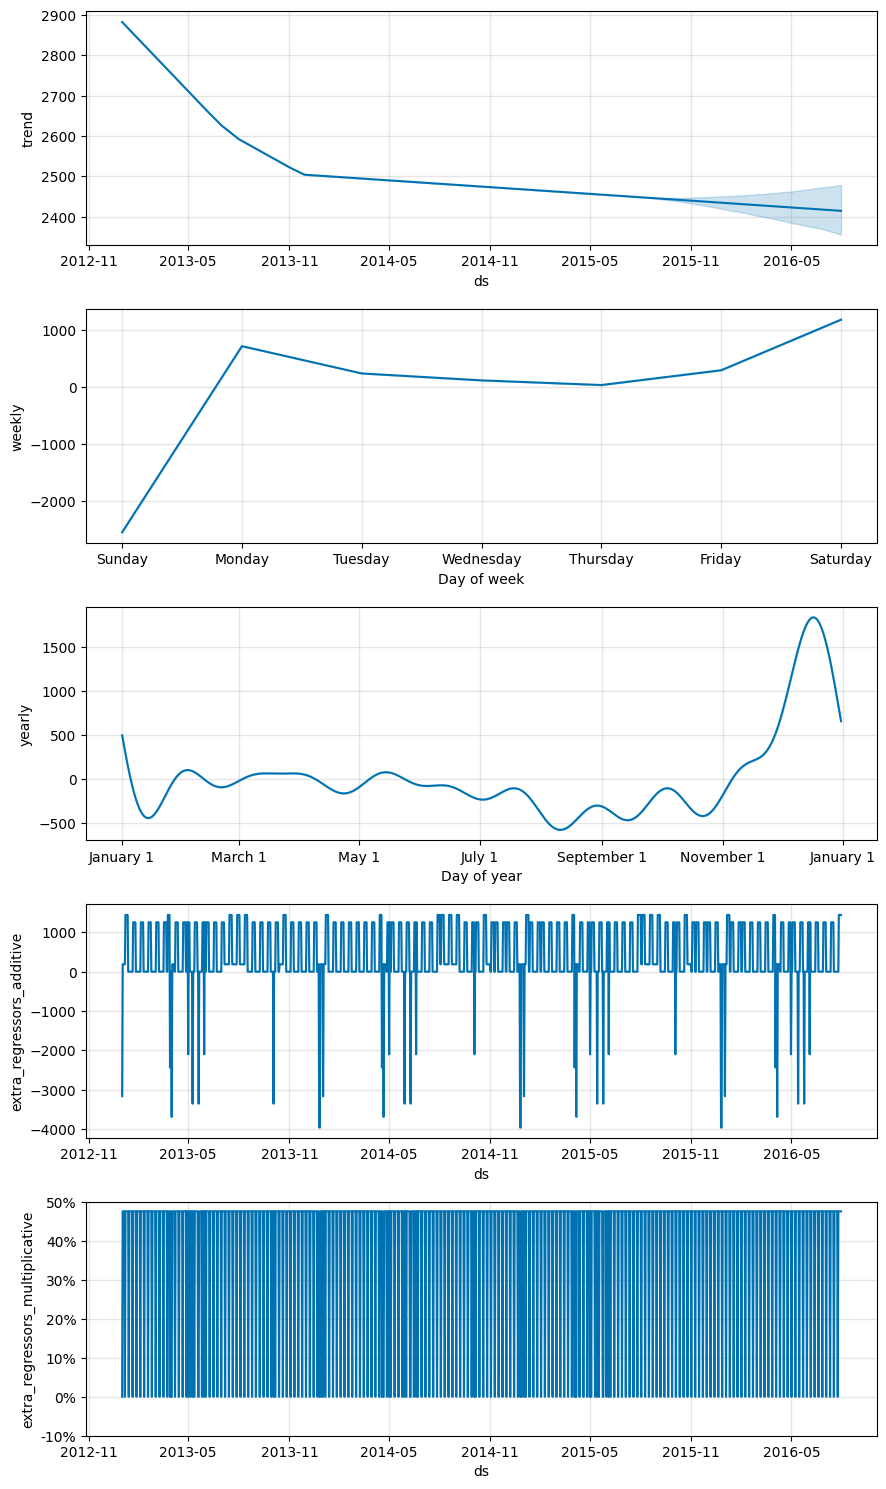

In [101]:
m4.plot_components(forecast4);

### CROSS VALIDATION

In [102]:
from prophet.diagnostics import cross_validation

In [103]:
df_cv = cross_validation(
    m, 
    initial='730 days',
    period='30 days',
    horizon='60 days'
)

  0%|          | 0/6 [00:00<?, ?it/s]15:55:19 - cmdstanpy - INFO - Chain [1] start processing
15:55:19 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:01,  3.38it/s]15:55:19 - cmdstanpy - INFO - Chain [1] start processing
15:55:19 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:01,  2.51it/s]15:55:19 - cmdstanpy - INFO - Chain [1] start processing
15:55:20 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:01<00:01,  2.57it/s]15:55:20 - cmdstanpy - INFO - Chain [1] start processing
15:55:20 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:01<00:00,  2.52it/s]15:55:20 - cmdstanpy - INFO - Chain [1] start processing
15:55:20 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:01<00:00,  2.75it/s]15:55:21 - cmdstanpy - INFO - Chain [1] start processing
15:55:21 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:02<00:00,  2.69it/s]


In [105]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-01-03,4615.071549,3185.360003,6059.422500,5023,2015-01-02
1,2015-01-04,-441.332764,-1922.057300,984.104236,0,2015-01-02
2,2015-01-05,4577.300112,3187.272678,6069.387483,6239,2015-01-02
3,2015-01-06,4192.545325,2663.722233,5617.134012,4574,2015-01-02
4,2015-01-07,3954.262739,2537.668877,5437.687076,4796,2015-01-02
...,...,...,...,...,...,...
355,2015-07-27,4793.193150,3343.880963,6231.172727,6102,2015-06-01
356,2015-07-28,4468.527277,3112.140074,5971.678835,5011,2015-06-01
357,2015-07-29,4253.992390,2844.163036,5683.835867,4782,2015-06-01
358,2015-07-30,3878.478597,2377.659275,5408.387387,5020,2015-06-01


In [106]:
# Let's check the performance through values. 
from prophet.diagnostics import performance_metrics

In [ ]:
pm = performance_metrics(df_cv)
pm
# As it computed these results from moving averages (starting from 10% of the data. ). So we have horizon of 60 days, so 10% will be 6, so it is started from 6 by using the previous 5 days moving averages for all these meterices. 


,horizon,mse,rmse,mae,mdape,smape,coverage
0,6 days,2.221903e+06,1490.605042,916.400909,0.136351,0.549672,0.805556
1,7 days,1.586058e+06,1259.387828,755.702199,0.131922,0.491074,0.833333
2,8 days,1.462228e+06,1209.226402,702.910104,0.121570,0.485751,0.888889
3,9 days,1.167759e+06,1080.629078,688.755974,0.144084,0.453643,0.916667
4,10 days,5.071604e+05,712.151981,578.831581,0.157248,0.460524,0.944444
5,11 days,4.990549e+05,706.438203,570.574504,0.149352,0.403887,0.944444
6,12 days,8.642033e+05,929.625348,635.786189,0.149352,0.450847,0.944444
7,13 days,8.332419e+05,912.820847,607.754198,0.135079,0.442366,0.944444
8,14 days,7.885268e+05,887.990303,569.340571,0.123264,0.433648,0.944444
9,15 days,6.591381e+05,811.873175,498.610817,0.103094,0.414846,0.972222


/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


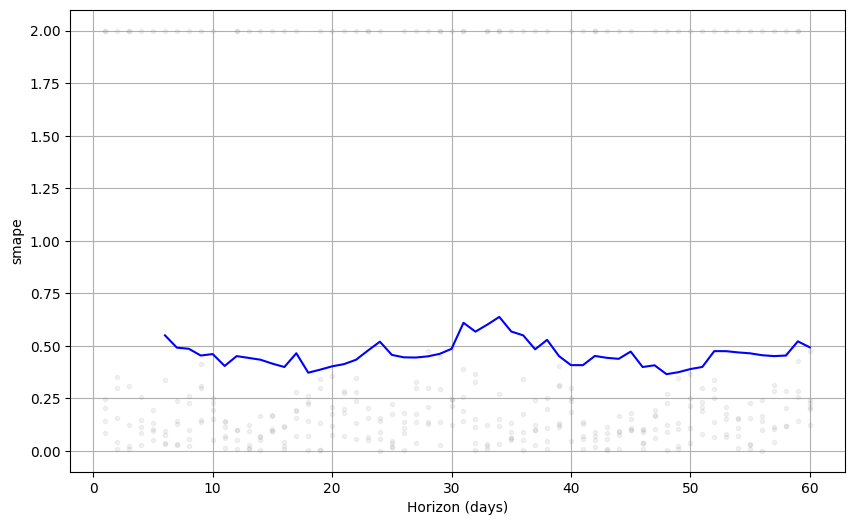

In [109]:
from prophet.plot import plot_cross_validation_metric
plot_cross_validation_metric(df_cv, metric='smape');

In [110]:
# Let's do the cv for second model. 
df_cv2 = cross_validation(m2, initial='730 days', period='30 days', horizon='60 days')
pm2 = performance_metrics(df_cv2)

  0%|          | 0/6 [00:00<?, ?it/s]16:02:14 - cmdstanpy - INFO - Chain [1] start processing
16:02:14 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:01,  2.53it/s]16:02:14 - cmdstanpy - INFO - Chain [1] start processing
16:02:14 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:01,  2.71it/s]16:02:15 - cmdstanpy - INFO - Chain [1] start processing
16:02:15 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:01<00:01,  2.60it/s]16:02:15 - cmdstanpy - INFO - Chain [1] start processing
16:02:15 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:01<00:00,  3.00it/s]16:02:15 - cmdstanpy - INFO - Chain [1] start processing
16:02:15 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:01<00:00,  3.42it/s]16:02:16 - cmdstanpy - INFO - Chain [1] start processing
16:02:16 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:01<00:00,  3.24it/s]


/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


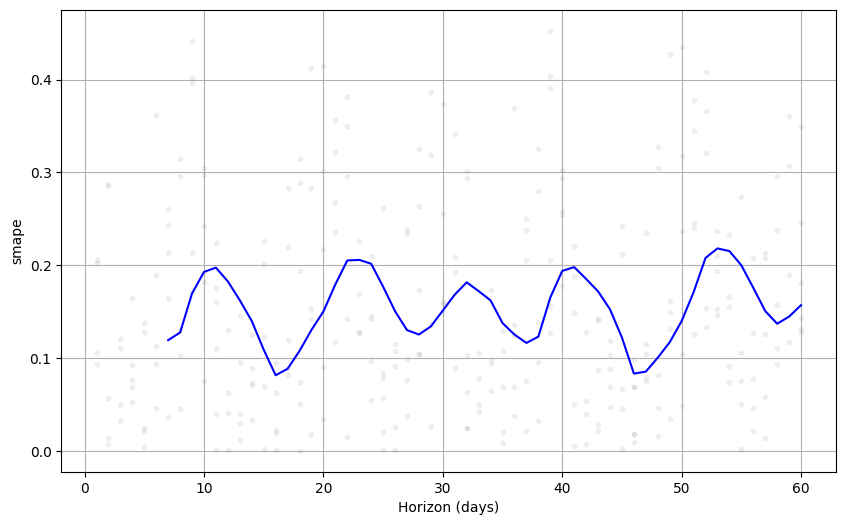

In [114]:
plot_cross_validation_metric(df_cv2, metric='smape');

In [117]:
# Let's do it for 3rd model
df_cv3 = cross_validation(m3, initial='730 days', period='30 days', horizon='60 days')
pm3 = performance_metrics(df_cv3)

  0%|          | 0/6 [00:00<?, ?it/s]

16:05:54 - cmdstanpy - INFO - Chain [1] start processing
16:05:54 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:04,  1.22it/s]16:05:55 - cmdstanpy - INFO - Chain [1] start processing
16:05:55 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:01<00:01,  2.00it/s]16:05:55 - cmdstanpy - INFO - Chain [1] start processing
16:05:55 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:01<00:01,  2.48it/s]16:05:55 - cmdstanpy - INFO - Chain [1] start processing
16:05:55 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:01<00:00,  2.77it/s]16:05:55 - cmdstanpy - INFO - Chain [1] start processing
16:05:55 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:01<00:00,  3.00it/s]16:05:56 - cmdstanpy - INFO - Chain [1] start processing
16:05:56 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:02<00:00,  2.60it/s]


/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


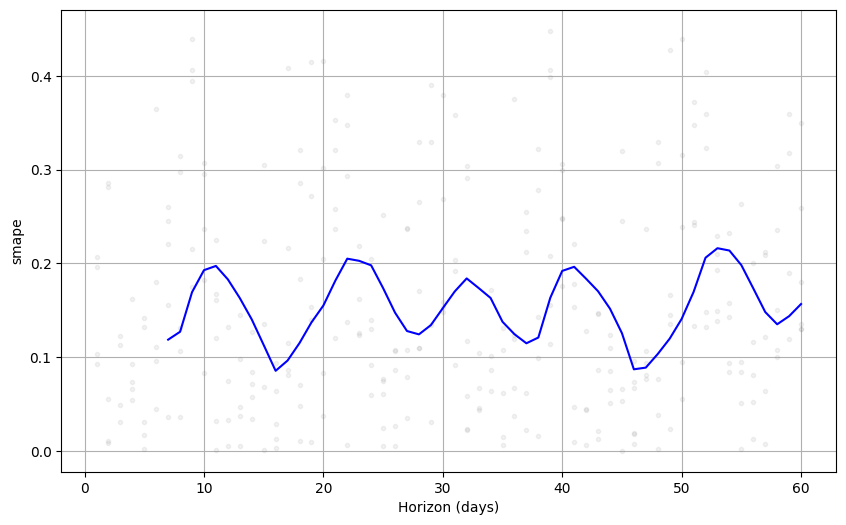

In [118]:
plot_cross_validation_metric(df_cv3, metric='smape');

In [119]:
# Let's do it for 4th. 
df_cv4 = cross_validation(m4, initial='730 days', period='30 days', horizon='60 days')
pm4 = performance_metrics(df_cv4)

  0%|          | 0/6 [00:00<?, ?it/s]16:06:11 - cmdstanpy - INFO - Chain [1] start processing
16:06:11 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:01,  2.74it/s]16:06:11 - cmdstanpy - INFO - Chain [1] start processing
16:06:11 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:01,  2.21it/s]16:06:12 - cmdstanpy - INFO - Chain [1] start processing
16:06:12 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:01<00:01,  1.78it/s]16:06:12 - cmdstanpy - INFO - Chain [1] start processing
16:06:12 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:02<00:01,  1.83it/s]16:06:13 - cmdstanpy - INFO - Chain [1] start processing
16:06:13 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:02<00:00,  2.06it/s]16:06:13 - cmdstanpy - INFO - Chain [1] start processing
16:06:13 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:02<00:00,  2.07it/s]


/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


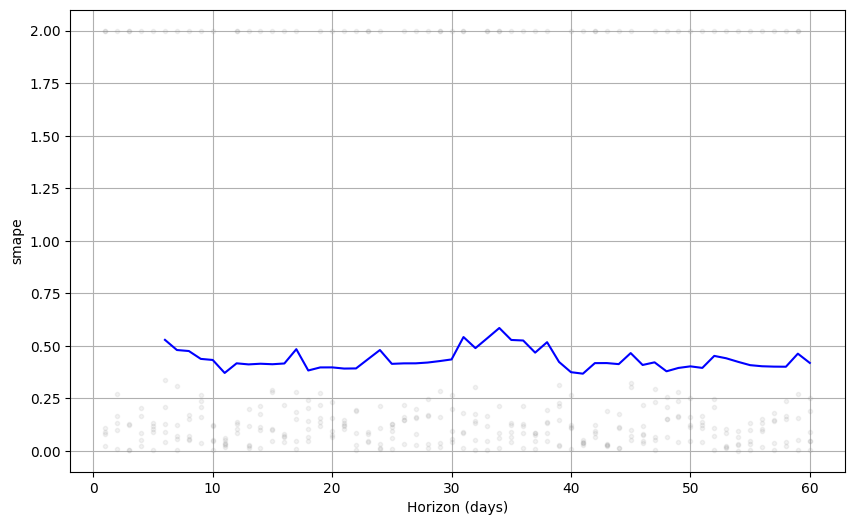

In [120]:
plot_cross_validation_metric(df_cv4, metric='smape');

In [123]:
pm['smape'].mean(), pm2['smape'].mean(), pm3['smape'].mean(), pm4['smape'].mean()

(0.46180290550140496,
 0.15407090901123766,
 0.15407090901123766,
 0.43577040463413264)

### ChangePoint Detection

In [124]:
# The change points detected automatically when we call fit on prophet. We will only visualize it now. 

from prophet.plot import add_changepoints_to_plot

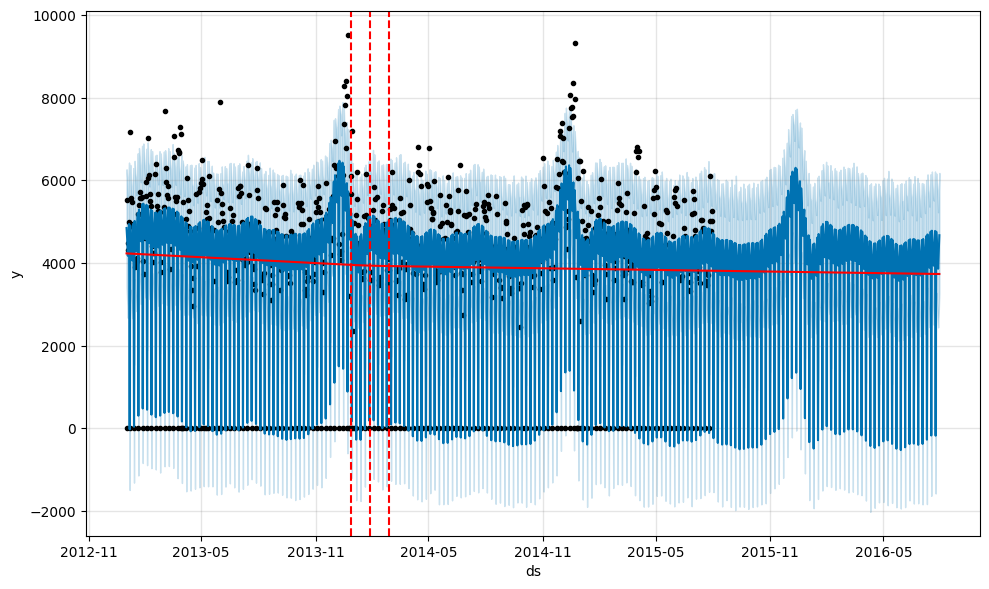

In [125]:
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast);

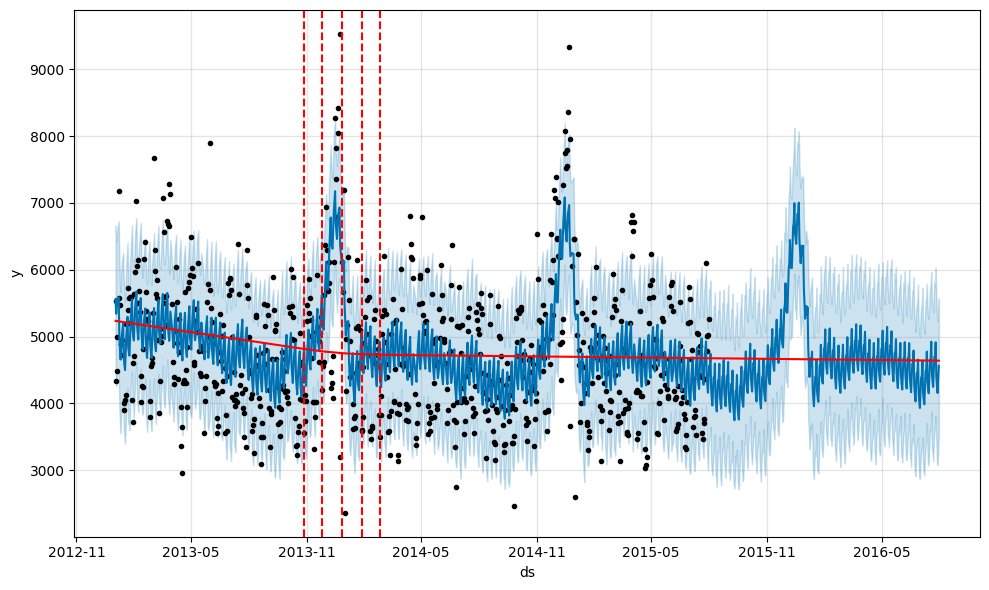

In [126]:
fig2 = m2.plot(forecast2)
a2 = add_changepoints_to_plot(fig2.gca(), m2, forecast2);

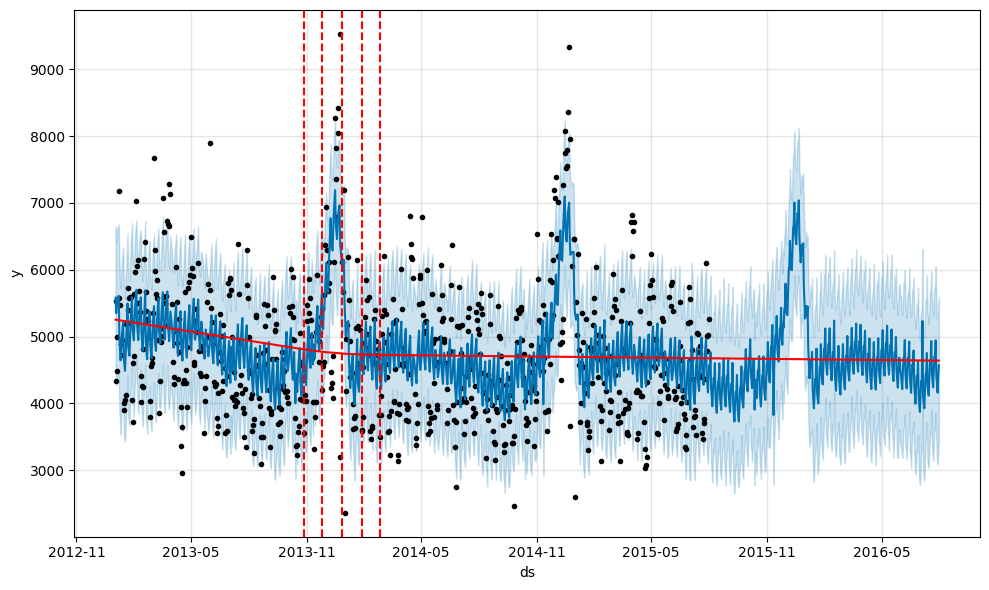

In [127]:
fig3 = m3.plot(forecast3)
a3 = add_changepoints_to_plot(fig3.gca(), m3, forecast3);

- Now we tune the prior for the changepoint detection and then see what will happen then.  